Conectando a la NOAA para descargar el producto Snow/Fog RGB (2026-08-13 13:50:00 UTC)...
Cargando desde disco...
Calibrando componentes físicos del producto Snow/Fog RGB...
Carimbo y logos adaptados correctamente.
¡Producto Snow/Fog RGB generado con éxito!: /Users/diegoperales/Meteorology/GOES/procesados/GOES19_DaySnowFog_SENAMHI_['Cochabamba']_20260813_1305.png


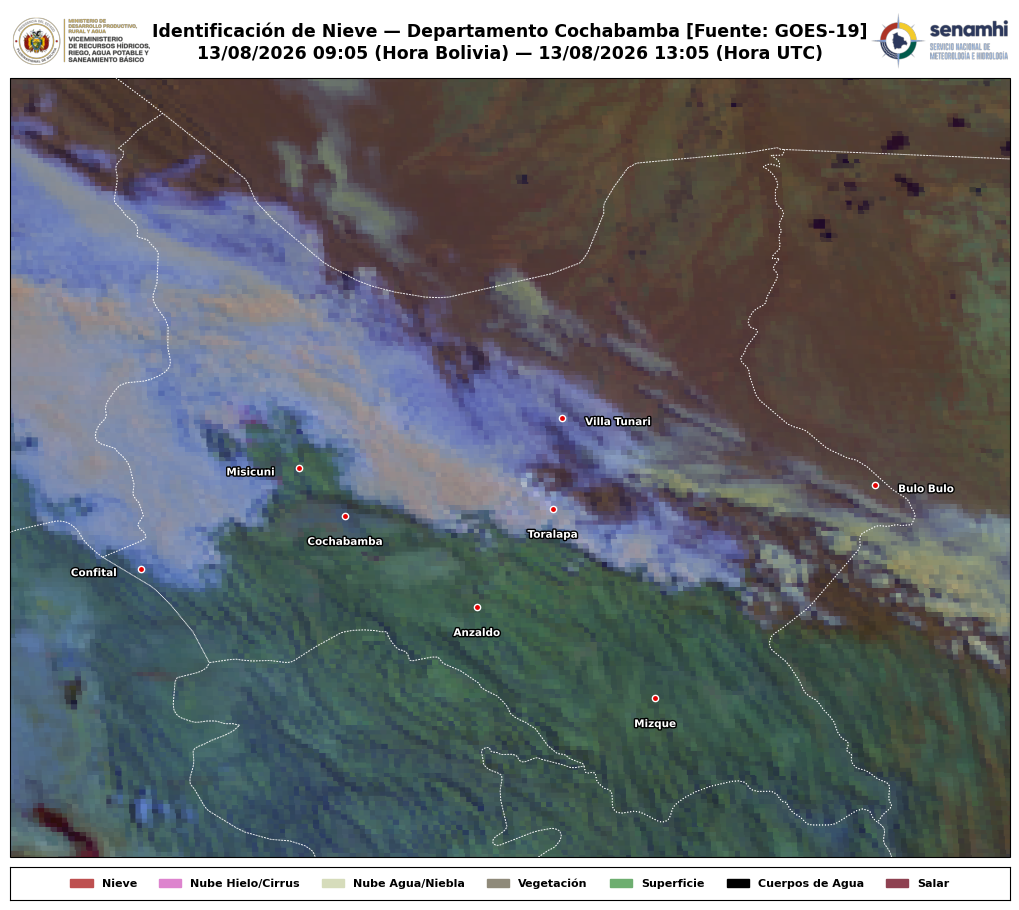

In [4]:
import os
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as patheffects
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import s3fs
import geopandas as gpd
import pandas as pd

# ==========================================
# FUNCIÓN AUXILIAR: EXTENT DINÁMICO (1 O MÁS DEPTS)
# ==========================================
def obtener_extent_departamento(shp_path, depto_identificador, target_aspect=1.052, buffer_pct=0.08):
    """
    Calcula el extent exacto [Oeste, Este, Sur, Norte] para encuadrar uno o varios departamentos.
    Acepta un string, entero o lista (ej. ["Potosi", "Oruro"] o [5, 4]).
    """
    if not os.path.exists(shp_path):
        raise FileNotFoundError(f"No se encontró el archivo shapefile en: {shp_path}")

    gdf = gpd.read_file(shp_path)
    
    # Normalizar entrada a lista
    if not isinstance(depto_identificador, list):
        deptos_list = [depto_identificador]
    else:
        deptos_list = depto_identificador

    # Construir máscara de filtrado
    mask = pd.Series(False, index=gdf.index)
    for elem in deptos_list:
        if isinstance(elem, int) or str(elem).isdigit():
            mask |= (gdf['cod_dep'] == int(elem))
        else:
            mask |= (gdf['nom_dep'].astype(str).str.contains(str(elem), case=False, na=False))

    dept = gdf[mask]

    if dept.empty:
        raise ValueError(f"No se encontraron los departamentos '{depto_identificador}' en el shapefile.")

    # 1. Obtener límites geográficos combinados [minx, miny, maxx, maxy]
    minx, miny, maxx, maxy = dept.total_bounds
    
    # 2. Calcular centro y margen (buffer)
    cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0
    w = (maxx - minx) * (1.0 + buffer_pct)
    h = (maxy - miny) * (1.0 + buffer_pct)
    
    # 3. Ajustar proporciones a la relación exacta del lienzo (10 / 9.5)
    if (w / h) < target_aspect:
        w = h * target_aspect
    else:
        h = w / target_aspect
        
    return [cx - w/2.0, cx + w/2.0, cy - h/2.0, cy + h/2.0]

# ==========================================
# 1. CONFIGURACIÓN DEL USUARIO
# ==========================================
FECHA_BUSCADA = datetime(2026, 8, 13, 13, 50) 

# Puedes usar un departamento o varios en una lista:
# Ejemplos: "Potosi", ["Potosi", "Oruro"], [2, 4, 5], "BOLIVIA"
REGION_OBJETIVO = ["Cochabamba"]

BASE_DIR = "/Users/diegoperales/Meteorology/GOES"
RAW_DATA = os.path.join(BASE_DIR, "raw_data")
OUTPUTS = os.path.join(BASE_DIR, "procesados")
os.makedirs(RAW_DATA, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

# Ruta exacta a tu archivo shapefile
PATH_SHP_DEPTS = os.path.join(BASE_DIR, "layers", "limites_departamentales.shp")

# Mapeo opcional de códigos a nombres para cuando uses números (ej. 5 -> POTOSI)
MAPA_CODIGOS = {
    1: "CHUQUISACA", 2: "LA PAZ", 3: "COCHABAMBA", 4: "ORURO",
    5: "POTOSI", 6: "TARIJA", 7: "SANTA CRUZ", 8: "BENI", 9: "PANDO"
}

# Traducir si se ingresó un entero
if isinstance(REGION_OBJETIVO, int):
    nombre_region_key = MAPA_CODIGOS.get(REGION_OBJETIVO, str(REGION_OBJETIVO))
else:
    nombre_region_key = str(REGION_OBJETIVO).upper()

# Catálogo de metadatos (locaciones y subtítulos)
LOCALIDADES_REGIONALES = {
    "BOLIVIA": {
        "subtitulo": "Bolivia — Cobertura Nacional",
        "localidades": {
            "Cobija":     {"lat": -11.02, "lon": -68.74, "pos": "top"},
            "Trinidad":   {"lat": -14.83, "lon": -64.90, "pos": "right"},
            "La Paz":     {"lat": -16.50, "lon": -68.15, "pos": "left"},
            "Cochabamba": {"lat": -17.38, "lon": -66.16, "pos": "top"},
            "Santa Cruz": {"lat": -17.78, "lon": -63.18, "pos": "right"},
            "Oruro":      {"lat": -17.98, "lon": -67.11, "pos": "left"},
            "Sucre":      {"lat": -19.03, "lon": -65.26, "pos": "right"},
            "Potosí":     {"lat": -19.58, "lon": -65.75, "pos": "left"},
            "Tarija":     {"lat": -21.53, "lon": -64.73, "pos": "bottom"}
        }
    },
    "LA PAZ": {
        "subtitulo": "Región La Paz",
        "localidades": {
            "El Alto":          {"lat": -16.50, "lon": -68.16, "pos": "left"},
            "La Paz":           {"lat": -16.84, "lon": -67.80, "pos": "right"},
            "Copacabana":       {"lat": -16.16, "lon": -69.08, "pos": "top"},
            "Achacachi":        {"lat": -16.04, "lon": -68.68, "pos": "right"},
            "Desaguadero":      {"lat": -16.56, "lon": -69.03, "pos": "left"},
            "Patacamaya":       {"lat": -17.23, "lon": -67.92, "pos": "right"},
            "Jesús de Machaca": {"lat": -16.77, "lon": -68.82, "pos": "left"},
            "Charaña":          {"lat": -17.59, "lon": -69.44, "pos": "right"},
            "Caranavi":         {"lat": -15.82, "lon": -67.56, "pos": "right"},
            "Apolo":            {"lat": -14.72, "lon": -68.42, "pos": "top"},
            "Ixiamas":          {"lat": -13.76, "lon": -68.12, "pos": "right"},
            "San Buenaventura": {"lat": -14.45, "lon": -67.65, "pos": "right"}
        }
    },
    "ORURO": {
        "subtitulo": "Región Oruro",
        "localidades": {
            "Oruro":                    {"lat": -17.98, "lon": -67.11, "pos": "right"},
            "Chipaya":                  {"lat": -19.04, "lon": -68.08, "pos": "right"},
            "Huanuni":                  {"lat": -18.28, "lon": -66.83, "pos": "left"},
            "Orinoca":                  {"lat": -18.97, "lon": -67.25, "pos": "top"},
            "Sajama":                   {"lat": -18.13, "lon": -68.97, "pos": "top"},
            "Chipaya":                  {"lat": -19.04, "lon": -68.08, "pos": "bottom"},
            "Pisiga":                   {"lat": -19.27, "lon": -68.57, "pos": "left"},
            "Salinas de Garci-Mendoza": {"lat": -19.64, "lon": -67.62, "pos": "bottom"}
        }
    },
    "POTOSI": {
        "subtitulo": "Región Potosí",
        "localidades": {
            "Potosí":               {"lat": -19.58, "lon": -65.75, "pos": "right"},
            "Uyuni":                {"lat": -20.46, "lon": -66.82, "pos": "top"},
            "Cotagaita":            {"lat": -20.55, "lon": -65.70, "pos": "right"},
            "Tupiza":               {"lat": -21.44, "lon": -65.72, "pos": "right"},
            "Villazón":             {"lat": -22.09, "lon": -65.59, "pos": "top"},
            "Uncía":                {"lat": -18.46, "lon": -66.56, "pos": "top"},
            "San Pablo de Lípez":   {"lat": -21.72, "lon": -66.62, "pos": "top"},
            "Colcha K":             {"lat": -20.76, "lon": -67.65, "pos": "bottom"},
            "Laguna Colorada":      {"lat": -22.17, "lon": -67.81, "pos": "left"}
            }
    },
    "COCHABAMBA": {
        "subtitulo": "Región Cochabamba",
        "localidades": {
            "Cochabamba":   {"lat": -17.38, "lon": -66.16, "pos": "bottom"},
            "Misicuni":     {"lat": -17.18, "lon": -66.32, "pos": "left"},
            "Confital":     {"lat": -17.60, "lon": -66.86, "pos": "left"},
            "Toralapa":     {"lat": -17.35, "lon": -65.45, "pos": "bottom"},
            "Anzaldo":      {"lat": -17.76, "lon": -65.71, "pos": "bottom"},
            "Mizque":       {"lat": -18.14, "lon": -65.10, "pos": "bottom"},
            "Bulo Bulo":    {"lat": -17.25, "lon": -64.35, "pos": "right"},
            "Villa Tunari": {"lat": -16.97, "lon": -65.42, "pos": "right"}
        }
    },
    "TARIJA": {
        "subtitulo": "Región Tarija",
        "localidades": {
            "Tarija":       {"lat": -21.54, "lon": -64.70, "pos": "bottom"},
            "San Lorenzo":  {"lat": -21.42, "lon": -64.75, "pos": "left"},
            "Campanario":   {"lat": -21.51, "lon": -65.06, "pos": "left"},
            "El Puente":    {"lat": -21.25, "lon": -65.20, "pos": "left"},
            "Bermejo":      {"lat": -22.73, "lon": -64.34, "pos": "bottom"},
            "Villamontes":  {"lat": -21.26, "lon": -63.47, "pos": "right"},
            "Yacuiba":      {"lat": -22.01, "lon": -63.68, "pos": "left"}
        }
    }
}

# --- LÓGICA DE ASIGNACIÓN DINÁMICA DE EXTENT Y METADATOS ---
if isinstance(REGION_OBJETIVO, str) and REGION_OBJETIVO.upper() == "BOLIVIA":
    extent_final = [-71.8, -55.2, -23.2, -9.5]
    subtitulo_final = LOCALIDADES_REGIONALES["BOLIVIA"]["subtitulo"]
    localidades_final = LOCALIDADES_REGIONALES["BOLIVIA"]["localidades"]
else:
    # 1. Extent combinado automático para todos los departamentos ingresados
    extent_final = obtener_extent_departamento(PATH_SHP_DEPTS, REGION_OBJETIVO)
    
    # 2. Unir localidades y nombres para la etiqueta
    if isinstance(REGION_OBJETIVO, list):
        nombres_deptos = []
        localidades_final = {}
        for d in REGION_OBJETIVO:
            key = MAPA_CODIGOS.get(d, str(d)).upper()
            nombres_deptos.append(key.title())
            # Combina las ciudades de los departamentos seleccionados si existen en el diccionario
            if key in LOCALIDADES_REGIONALES:
                localidades_final.update(LOCALIDADES_REGIONALES[key]["localidades"])
        
        subtitulo_final = f"Departamento { ' - '.join(nombres_deptos) }"
    else:
        info_reg = LOCALIDADES_REGIONALES.get(nombre_region_key, {})
        subtitulo_final = info_reg.get("subtitulo", f"Departamento {nombre_region_key.title()}")
        localidades_final = info_reg.get("localidades", {})

BASE_DIR = "/Users/diegoperales/Meteorology/GOES"
RAW_DATA = os.path.join(BASE_DIR, "raw_data")
OUTPUTS = os.path.join(BASE_DIR, "procesados")
os.makedirs(RAW_DATA, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

# ==========================================
# 2. CONEXIÓN A AMAZON S3
# ==========================================
print(f"Conectando a la NOAA para descargar el producto Snow/Fog RGB ({FECHA_BUSCADA} UTC)...")
fs = s3fs.S3FileSystem(anon=True)

doy = FECHA_BUSCADA.strftime('%j') 
anio = FECHA_BUSCADA.strftime('%Y')
hora = FECHA_BUSCADA.strftime('%H')

s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora}/"

try:
    archivos = fs.ls(s3_folder)
    archivos_multi = [f for f in archivos if f.endswith('.nc')]
    
    if not archivos_multi:
        print(f"Alerta: No hay datos en la hora {hora}. Intentando buscar un bloque antes...")
        hora_alterna = f"{int(hora)-1:02d}"
        s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora_alterna}/"
        archivos = fs.ls(s3_folder)
        archivos_multi = [f for f in archivos if f.endswith('.nc')]
        
    s3_path = archivos_multi[0]
    file_name = s3_path.split('/')[-1]
    local_path = os.path.join(RAW_DATA, file_name)
    
    if not os.path.exists(local_path):
        print(f"Descargando archivo multibanda: {file_name}...")
        fs.get(s3_path, local_path)
    else:
        print("Cargando desde disco...")
        
    ds = xr.open_dataset(local_path)

except Exception as e:
    print(f"Error crítico: {e}")
    raise e

# ==========================================
# 3. PROYECCIÓN SATELITAL
# ==========================================
glob_attrs = ds.goes_imager_projection.attrs
height = glob_attrs['perspective_point_height']
lon_0 = glob_attrs['longitude_of_projection_origin']
sweep = glob_attrs['sweep_angle_axis']

dataprojenv = ccrs.Geostationary(central_longitude=lon_0, satellite_height=height, sweep_axis=sweep)

# ==========================================
# 4. COMPOSICIÓN SNOW/ICE
# ==========================================
print("Calibrando componentes físicos del producto Snow/Fog RGB...")

ch03_raw = ds['CMI_C03'].data.astype(float)  # 0.86 µm
ch05_raw = ds['CMI_C05'].data.astype(float)  # 1.60 µm
ch07_raw = ds['CMI_C07'].data.astype(float)  # 3.90 µm
ch13_raw = ds['CMI_C13'].data.astype(float)  # 10.30 µm

ch03_pct = ch03_raw if np.max(ch03_raw) > 1.0 else ch03_raw * 100.0
ch05_pct = ch05_raw if np.max(ch05_raw) > 1.0 else ch05_raw * 100.0

# Rojo (Canal 3)
R_min, R_max = 0.0, 100.0
R = (ch03_pct - R_min) / (R_max - R_min)
R = np.clip(R, 0, 1)
R = np.power(R, 1.0 / 1.7)

# Verde (Canal 5)
G_min, G_max = 0.0, 70.0
G = (ch05_pct - G_min) / (G_max - G_min)
G = np.clip(G, 0, 1)
G = np.power(G, 1.0 / 1.7)

# Azul (Ch07 - Ch13)
blue_diff = ch07_raw - ch13_raw
B_min, B_max = 0.0, 30.0
B = (blue_diff - B_min) / (B_max - B_min)
B = np.clip(B, 0, 1)
B = np.power(B, 1.0 / 1.7)

rgb_image = np.dstack((R, G, B))

# ==========================================
# 5. GENERACIÓN DEL PRODUCTO VISUAL
# ==========================================
# Configuración del lienzo
fig, ax = plt.subplots(figsize=(10, 9.5), facecolor='white', subplot_kw={'projection': ccrs.PlateCarree()})

# Ajuste de márgenes externos
fig.subplots_adjust(left=0.00, right=1.00, top=0.88, bottom=0.06)

# --- AJUSTE GEOGRÁFICO EQUILIBRADO SEGÚN EL DEPARTAMENTO O REGIÓN ---
ax.set_extent(extent_final, crs=ccrs.PlateCarree())

# --- EFECTO BORDERLESS ---
X_grid = ds.x.data * height
Y_grid = ds.y.data * height

# imshow con aspect='auto' es más rápido y exacto
x_min, x_max = X_grid.min(), X_grid.max()
y_min, y_max = Y_grid.min(), Y_grid.max()

# Eestirar la imagen satelital para rellenar los bordes laterales vacíos
ax.imshow(rgb_image, origin='upper', transform=dataprojenv, 
          extent=[x_min, x_max, y_min, y_max], aspect='auto', zorder=1)

# --- CAPA 2: LÍMITES GEOGRÁFICOS PERFECTAMENTE ALINEADOS ---
COLOR_BLANCO = '#ffffff'
ax.add_feature(cfeature.COASTLINE, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=(0, (1, 2)), edgecolor=COLOR_BLANCO, linewidth=0.7, zorder=4)

# --- CAPA 3: LAS 9 CAPITALES DE DEPARTAMENTO DE BOLIVIA ---
capitales = {
    "Cobija":       {"lat": -11.02, "lon": -68.74, "pos": "top"},
    "Trinidad":     {"lat": -14.83, "lon": -64.90, "pos": "right"},
    "La Paz":       {"lat": -16.50, "lon": -68.15, "pos": "left"},
    "Cochabamba":   {"lat": -17.38, "lon": -66.16, "pos": "top"},
    "Santa Cruz":   {"lat": -17.78, "lon": -63.18, "pos": "right"},
    "Oruro":        {"lat": -17.98, "lon": -67.11, "pos": "left"},
    "Sucre":        {"lat": -19.03, "lon": -65.26, "pos": "right"},
    "Potosí":       {"lat": -19.58, "lon": -65.75, "pos": "left"},
    "Tarija":       {"lat": -21.53, "lon": -64.73, "pos": "bottom"}
}

# El bucle ahora lee el diccionario de la región activa:
for ciudad, info in localidades_final.items():
    ax.plot(info["lon"], info["lat"], marker='o', color='#E50001', markersize=4.5, 
            markeredgecolor='white', markeredgewidth=1.0, transform=ccrs.PlateCarree(), zorder=10)
    
    offset_lon = 0.08 if info["pos"] == "right" else (-0.08 if info["pos"] == "left" else 0)
    offset_lat = 0.08 if info["pos"] == "top" else (-0.12 if info["pos"] == "bottom" else -0.03)
    alignment_h = "left" if info["pos"] == "right" else ("right" if info["pos"] == "left" else "center")
    
    ax.text(info["lon"] + offset_lon, info["lat"] + offset_lat, ciudad, color='white', 
            fontsize=7.5, fontweight='bold', horizontalalignment=alignment_h, 
            transform=ccrs.PlateCarree(), zorder=11, 
            path_effects=[patheffects.withStroke(linewidth=2, foreground='black')])

# --- CAPA 4: PROCESAMIENTO DE FECHAS ---
fecha_utc = datetime.strptime(ds.t.dt.strftime('%Y-%m-%d %H:%M').item(), '%Y-%m-%d %H:%M')
fecha_bot = fecha_utc - timedelta(hours=4)
string_utc = fecha_utc.strftime('%d/%m/%Y %H:%M (Hora UTC)')
string_bot = fecha_bot.strftime('%d/%m/%Y %H:%M (Hora Bolivia)')

# --- CAPA 5: TÍTULO CORPORATIVO ADAPTADO ---
# El título se actualiza automáticamente según la región:
ax.set_title(
    f"Identificación de Nieve — {subtitulo_final} [Fuente: GOES-19]\n"
    f"{string_bot} — {string_utc}", 
    fontsize=12.5, fontweight='bold', pad=14, loc='center', linespacing=1.3
)

# --- CAPA 6: LEYENDA HORIZONTAL ---
pos_mapa = ax.get_position()
ax_leyenda = fig.add_axes([0.00, pos_mapa.y0 - 0.045, 1.00, 0.035]) # Forzamos ancho completo 0.00 a 1.00
ax_leyenda.set_facecolor('#ffffff')
ax_leyenda.set_xticks([])
ax_leyenda.set_yticks([])

parches_leyenda = [
    mpatches.Patch(color='#BE5050', label='Nieve'), 
    mpatches.Patch(color='#DD84CE', label='Nube Hielo/Cirrus'),
    mpatches.Patch(color='#D6DCBB', label='Nube Agua/Niebla'),
    mpatches.Patch(color='#8F8A7A', label='Vegetación'),
    mpatches.Patch(color='#6EAE70', label='Superficie'),
    mpatches.Patch(color='#000000', label='Cuerpos de Agua'),
    mpatches.Patch(color='#8E4151', label='Salar')
]

leyenda = ax_leyenda.legend(handles=parches_leyenda, loc='center', ncol=7, frameon=False, fontsize=8.0)

for text in leyenda.get_texts():
    text.set_color('black')
    text.set_weight('bold')

# --- CAPA 7: INSERCIÓN DE LOGOS ---
PATH_LOGOS = os.path.join(BASE_DIR, "logos")
try:
    img_ministerio_path = os.path.join(PATH_LOGOS, "logo_ministerio.png")
    img_senamhi_path = os.path.join(PATH_LOGOS, "logo_senamhi.png")
    
    if os.path.exists(img_ministerio_path) and os.path.exists(img_senamhi_path):
        logo_ministerio = mpimg.imread(img_ministerio_path)
        logo_senamhi = mpimg.imread(img_senamhi_path)
        
        ax_logo_min = fig.add_axes([pos_mapa.x0, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_min.imshow(logo_ministerio)
        ax_logo_min.axis('off')
        
        ax_logo_sen = fig.add_axes([pos_mapa.x1 - 0.14, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_sen.imshow(logo_senamhi)
        ax_logo_sen.axis('off')
        print("Carimbo y logos adaptados correctamente.")
except Exception as e:
    print(f"Alerta logos: {e}")

# El archivo final guardará la palabra del mapa generado (ej. ..._POTOSI_2026...)
output_name = f"{OUTPUTS}/GOES19_DaySnowFog_SENAMHI_{REGION_OBJETIVO}_{fecha_utc.strftime('%Y%m%d_%H%M')}.png"

plt.savefig(output_name, dpi=200, bbox_inches='tight', pad_inches=0.03)
print(f"¡Producto Snow/Fog RGB generado con éxito!: {output_name}")

plt.show()